# Chapter 2 — Shared memory: increasing reuse with a moving average

This notebook follows the adjacent-differences example. We compare the **same
moving average** computed by `moving_average_direct` and `moving_average_shared`.
For radius R, each output sums 2R+1 samples and divides by 2R+1. Values outside
the input array are zero, and the denominator remains 2R+1 at the boundaries.

**Learning goals:** follow the overlapping input windows, identify the central
tile and two halos, distribute buffer loads among threads, understand why every
thread reaches the barrier, and measure when reuse compensates for that work.

All diagrams, GPU output tables, timings, and timing plots appear in notebook
cells. No figure, CSV, Excel, or result archive is exported. Only CUDA sources
and the executable are written, as required for compilation. Save the notebook
with its outputs to retain the experiment.

The supplied notebook contains no fabricated GPU measurements. Execute its cells
on an NVIDIA GPU to generate results. Matplotlib draws the explanatory diagrams;
these are exact indexing schematics, not measured GPU output.

In [ ]:
!pip install pycuda

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 4.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.8/101.8 kB 9.5 MB/s eta 0:00:00
  Created wheel for pycuda: filename=pycuda-2026.1-cp313-cp313-linux_x86_64.whl size=5281327 sha256=cdd80f6704d86d9d45be8130bae810ebfaa1335ca62537bb67ef81f6e6eaf781
  Stored in directory: /root/.cache/pip/wheels/ce/26/46/c519675fcb0e5e17bab8e85b6676528c40d12d794182340e85
Successfully built pycuda


## 1. Select and inspect a GPU runtime

In Colab select **Runtime → Change runtime type → GPU**. We use `%%writefile`
and `nvcc`, without nvcc4jupyter, PyCUDA, or CuPy. The `!` commands below run
in the remote Linux environment. `nvidia-smi` describes driver support;
`nvcc --version` identifies the available compiler.

In [ ]:
!nvidia-smi
!nvcc --version
!mkdir -p code

Thu Oct  8 17:59:21 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2. Follow the direct reads

Take an interior block with B=4, first output index 8, and R=2. The outputs
y[8], ..., y[11] each require five samples. Together they issue 20 source-level
input reads involving only eight distinct values, a[6], ..., a[13].

The **central tile** is a[8], ..., a[11], corresponding to the output indices.
The **left halo** is a[6], a[7]; the **right halo** is a[12], a[13]. Halo values
are ordinary inputs outside this block's central portion. They are distinct
from the zeros substituted for positions outside the entire array.

`moving_average_direct`, defined below, reads its window directly from global
memory. Hardware caches may supply repeated inputs without another DRAM fetch.
The diagram counts source-level dependencies, not physical memory transactions.

In [ ]:
"""Exact schematic diagrams, not measured GPU output. Reusable stencil palette."""
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch, Patch

BLUE='#236EA3'; LIGHT_BLUE='#DBECF7'
ORANGE='#B96513'; LIGHT_ORANGE='#FCE6CA'
GREEN='#207B58'; LIGHT_GREEN='#E0F0E8'
GRAY='#6E7882'; LIGHT_GRAY='#E9ECEF'; INK='#23313E'
plt.rcParams.update({'font.family':'DejaVu Sans','font.size':11,
                     'pdf.fonttype':42,'svg.fonttype':'none'})

def canvas(title,height=6.0,count=5):
    fig,ax=plt.subplots(figsize=(8.5,height))
    ax.set_xlim(-.75,float(count));ax.set_ylim(-.15,6.7);ax.axis('off')
    ax.text(-.65,6.47,title,fontsize=14,weight='bold',color=INK)
    return fig,ax

def cell(ax,x,y,label,kind='core',w=.84,h=.6,fs=13):
    edge,face={'core':(BLUE,LIGHT_BLUE),'halo':(ORANGE,LIGHT_ORANGE),
               'output':(GREEN,LIGHT_GREEN),'invalid':(GRAY,LIGHT_GRAY)}[kind]
    ax.add_patch(Rectangle((x-w/2,y-h/2),w,h,facecolor=face,edgecolor=edge,
                           linewidth=1.5,hatch='///' if kind=='invalid' else None,zorder=3))
    ax.text(x,y,label,ha='center',va='center',fontsize=fs,color=INK,zorder=4)

def arrow(ax,a,b,color=BLUE):
    ax.add_patch(FancyArrowPatch(a,b,arrowstyle='-|>',mutation_scale=11,
                                 lw=1.3,color=color,zorder=2))

def bracket(ax,left,right,y,text,color):
    ax.plot([left,left,right,right],[y-.1,y,y,y-.1],color=color,lw=1.3)
    ax.text((left+right)/2,y+.08,text,ha='center',va='bottom',color=color,fontsize=11)


def global_reuse(B=4,radius=2,first=8):
    count=B+2*radius
    fig,ax=canvas(f'A. Direct kernel: {2*radius+1} input reads per thread',5.1,count)
    ax.text(-.65,5.83,f'Interior block: B = {B}, R = {radius}, first output index j = {first}',color=GRAY)
    for q in range(count):
        kind='halo' if q<radius or q>=radius+B else 'core'
        cell(ax,q,4.65,rf'$a_{{{first-radius+q}}}$',kind)
    if radius:
        bracket(ax,-.42,radius-.58,5.17,'Left halo',ORANGE)
        bracket(ax,radius+B-.42,count-.58,5.17,'Right halo',ORANGE)
    bracket(ax,radius-.42,radius+B-.58,5.17,'Central tile',BLUE)
    for t in range(B):
        x=t+radius
        for r in range(2*radius+1):
            q=t+r
            color=ORANGE if q<radius or q>=radius+B else BLUE
            offset=0 if radius==0 else -.22+.44*r/(2*radius)
            arrow(ax,(q,4.33),(x+offset,2.97),color)
        cell(ax,x,2.48,rf'$t={t}$'+'\n'+rf'$y_{{{first+t}}}$',
             'output',w=.98,h=.92,fs=11)
    center=(count-1)/2
    ax.text(center,1.48,f'Only {count} distinct input values are needed by this block.',
            ha='center',color=INK)
    ax.text(center,.86,f'{B} outputs  ×  {2*radius+1} global input reads  =  {B*(2*radius+1)} source-level reads',
            ha='center',weight='bold',color=INK)
    ax.text(center,.27,'Arrows show input dependencies, not DRAM transactions.',
            ha='center',fontsize=10,color=GRAY)
    return fig

def shared_tiling(partial=False):
    B=4;radius=2;first=8;count=B+2*radius;selected=1
    title='C. Last block: all threads reach the barrier' if partial else 'B. Shared kernel: load, synchronize, reuse'
    fig,ax=canvas(title,7.0,count)
    ax.text(-.65,5.99,'B = 4, R = 2, j = 8, N = 10: only outputs y8 and y9 are valid' if partial else
            'Interior block: B = 4, R = 2, first output index j = 8',color=GRAY)
    for q in range(count):
        k=first+q-radius
        invalid=partial and k>=10
        kind='invalid' if invalid else ('halo' if q<radius or q>=radius+B else 'core')
        color=GRAY if invalid else (ORANGE if kind=='halo' else BLUE)
        cell(ax,q,5.23,'outside\narray' if invalid else rf'$a_{{{k}}}$',kind,fs=10 if invalid else 13)
        if not invalid:arrow(ax,(q,4.91),(q,3.92),color)
        ax.text(q,4.39,(f't{q%B}:\nwrite zero\n(pass {q//B+1})' if invalid else f't{q%B}: load\n(pass {q//B+1})'),
                ha='center',va='center',fontsize=9,color=color,
                bbox={'facecolor':'white','edgecolor':'none','pad':2},zorder=5)
        cell(ax,q,3.53,('0' if invalid else rf'$a_{{{k}}}$')+'\n'+f'tile[{q}]',kind,h=.74,fs=12)
    bracket(ax,-.42,1.42,5.63,'Left halo',ORANGE)
    bracket(ax,1.58,5.42,5.63,'Central tile',BLUE)
    bracket(ax,5.58,7.42,5.63,'Right halo',ORANGE)
    # Highlight one window, while retaining the same blue/orange read arrows.
    ax.add_patch(Rectangle((selected-.46,3.10),2*radius+.92,.86,
                          fill=False,edgecolor=GREEN,linewidth=1.5,zorder=5))
    center=(count-1)/2
    ax.plot([-.45,count-.55],[2.32,2.32],ls='--',color=INK,lw=1.4)
    ax.text(center,2.32,'  __syncthreads(): all 4 threads  ',ha='center',va='center',
            bbox={'facecolor':'white','edgecolor':'none','pad':3},fontfamily='monospace',fontsize=11,zorder=6)
    for q in range(selected,selected+2*radius+1):
        kind='halo' if q<radius or q>=radius+B else 'core'
        color=ORANGE if kind=='halo' else BLUE
        offset=-.22+.44*(q-selected)/(2*radius)
        arrow(ax,(q,3.08),(selected+radius+offset,1.73),color)
    for t in range(B):
        valid=not partial or t<2
        cell(ax,t+radius,1.23,rf'$t={t}$'+'\n'+(rf'$y_{{{first+t}}}$' if valid else 'skip write'),
             'output' if valid else 'invalid',w=.98,h=.92,fs=11)
    ax.text(center,.42,'Green window: thread 1 reads tile[1] ... tile[5] for y9.',
            ha='center',color=INK,fontsize=11)
    ax.text(center,.02,'Gray slots receive zero without an out-of-bounds input read.' if partial else
            'B + 2R = 8 shared slots: eight global reads supply four outputs.',
            ha='center',color=GRAY,fontsize=10)
    return fig


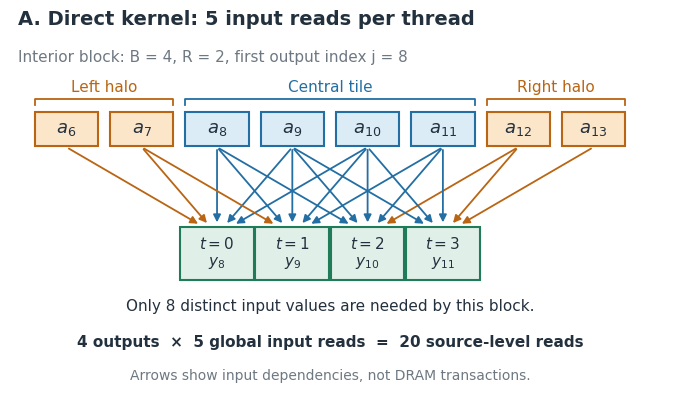

In [ ]:
from IPython.display import display
fig=global_reuse(B=4,radius=2,first=8)
display(fig)
plt.close(fig)

## 3. Write both CUDA kernels

`moving_average_direct` reads its own window, checks array boundaries, and writes
one average. It requires neither a shared-memory buffer nor a block barrier.

`moving_average_shared` uses **B+2R shared slots**. Slot q represents input
`first+q-R`. Thread t loads q=t, t+B, t+2B, ... until the whole buffer is filled.
For B=4 and R=2, thread zero loads slots 0 and 4, thread one loads 1 and 5,
thread two loads 2 and 6, and thread three loads 3 and 7. This scheme works
even when the halo radius exceeds the block size: each thread does more loads.

After `__syncthreads()`, thread t sums slots t through t+2R. The center of that
window is slot t+R. The radius is a runtime parameter, so both kernels implement
the same arithmetic loop rather than different compile-time specializations.

In [ ]:
%%writefile code/chapter02_moving_average_kernels.cuh
#ifndef BOOK_MOVING_AVERAGE_KERNELS_CUH
#define BOOK_MOVING_AVERAGE_KERNELS_CUH

extern "C" __global__
void moving_average_direct(const float *a, float *y, int n, int radius)
{
    const int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i < n) {
        float sum = 0.0f;
        for (int r = -radius; r <= radius; ++r) {
            const int k = i + r;
            if (k >= 0 && k < n) sum += a[k];
        }
        y[i] = sum / float(2 * radius + 1);
    }
}

extern "C" __global__
void moving_average_shared(const float *a, float *y, int n, int radius)
{
    extern __shared__ float tile[];
    const int t = threadIdx.x;
    const int first = blockIdx.x * blockDim.x;
    const int width = blockDim.x + 2 * radius;

    for (int q = t; q < width; q += blockDim.x) {
        const int k = first + q - radius;
        tile[q] = (k >= 0 && k < n) ? a[k] : 0.0f;
    }
    __syncthreads();

    const int i = first + t;
    if (i < n) {
        float sum = 0.0f;
        for (int r = -radius; r <= radius; ++r) {
            sum += tile[t + radius + r];
        }
        y[i] = sum / float(2 * radius + 1);
    }
}
#endif

Writing code/chapter02_moving_average_kernels.cuh


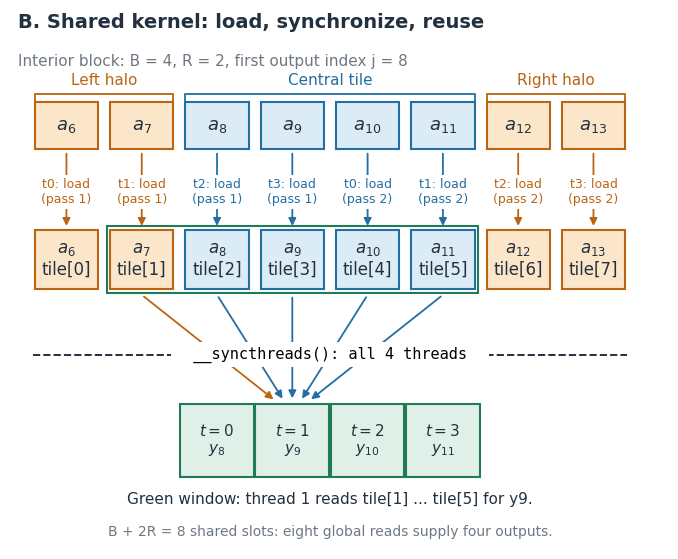

In [ ]:
fig=shared_tiling()
display(fig)
plt.close(fig)

## 4. Handle both array boundaries and partial blocks

For N=10, B=4, R=2, the last block starts at output index 8. Its buffer represents
a[6], ..., a[13]. The valid inputs are a[6], ..., a[9]; positions 10 through 13
are replaced by zero. All four threads load their assigned slots and reach the
barrier. Only threads zero and one write outputs, y[8] and y[9].

In the first block, negative input positions are handled the same way. Each
block reads its own halo from global memory, not from another block's buffer.
Never return early for an invalid output before the loading loop and barrier:
that thread can still be responsible for an input required by a valid output.

The denominator is always five for R=2, including y[0] and y[N-1]. This is an
average of a **zero-extended array**, not an average over only valid samples.

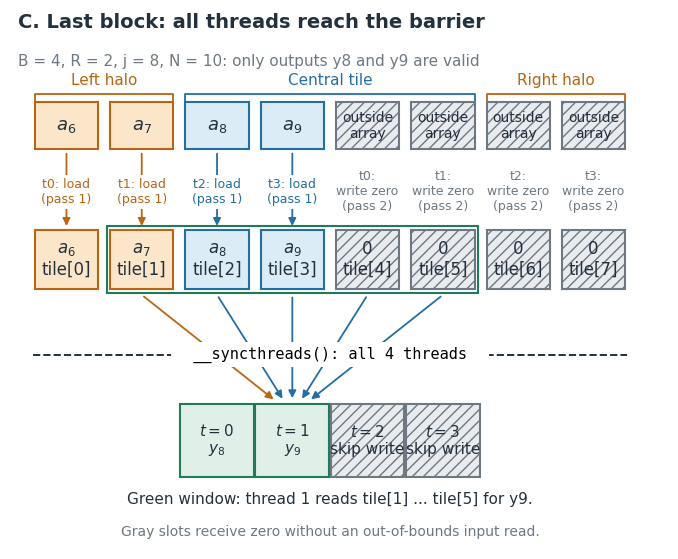

In [ ]:
fig=shared_tiling(partial=True)
display(fig)
plt.close(fig)

## 5. Timing support and host program

We reuse the author's adapted `TimingGPU` interface. Its CUDA events are checked,
reused, and released; `GetCounter()` waits and returns milliseconds. The shared
kernel is launched with `(B+2R)*sizeof(float)` dynamic shared bytes per block.
The program checks device limits before launches.

The host compares every GPU output with a double-precision CPU reference using
a floating-point tolerance. Output buffers are filled with NaNs before validation
to detect missing writes. We do not time the CPU reference or claim CPU speedup.

In [ ]:
%%writefile code/cuda_check.cuh
#ifndef BOOK_CUDA_CHECK_CUH
#define BOOK_CUDA_CHECK_CUH
#include <cuda_runtime.h>
#include <cstdio>
#include <cstdlib>
#define CUDA_CHECK(call) do { \
    const cudaError_t status_ = (call); \
    if (status_ != cudaSuccess) { \
        std::fprintf(stderr, "%s:%d: %s\n", __FILE__, __LINE__, \
                     cudaGetErrorString(status_)); \
        std::exit(EXIT_FAILURE); \
    } \
} while (0)
#endif

Writing code/cuda_check.cuh


In [ ]:
%%writefile code/TimingGPU.cuh
#ifndef BOOK_TIMING_GPU_CUH
#define BOOK_TIMING_GPU_CUH
// Adapted from the author's Timing.zip for repeated notebook experiments.
// Same public timing methods; errors checked and resources released.
struct PrivateTimingGPU;
class TimingGPU {
    PrivateTimingGPU *privateTimingGPU;
    void Start(unsigned int flags);
public:
    TimingGPU();
    ~TimingGPU();
    TimingGPU(const TimingGPU&) = delete;
    TimingGPU& operator=(const TimingGPU&) = delete;
    void StartCounter();
    void StartCounterFlags();
    float GetCounter(); // milliseconds; waits for the stop event
};
#endif

Writing code/TimingGPU.cuh


In [ ]:
%%writefile code/TimingGPU.cu
#include "TimingGPU.cuh"
#include "cuda_check.cuh"

struct PrivateTimingGPU {
    cudaEvent_t start, stop;
    unsigned int flags;
    bool started;
};

TimingGPU::TimingGPU() : privateTimingGPU(new PrivateTimingGPU{}) {
    CUDA_CHECK(cudaEventCreate(&privateTimingGPU->start));
    CUDA_CHECK(cudaEventCreate(&privateTimingGPU->stop));
}

TimingGPU::~TimingGPU() {
    CUDA_CHECK(cudaEventDestroy(privateTimingGPU->start));
    CUDA_CHECK(cudaEventDestroy(privateTimingGPU->stop));
    delete privateTimingGPU;
}

void TimingGPU::Start(unsigned int flags) {
    if (flags != privateTimingGPU->flags) {
        CUDA_CHECK(cudaEventDestroy(privateTimingGPU->start));
        CUDA_CHECK(cudaEventDestroy(privateTimingGPU->stop));
        CUDA_CHECK(cudaEventCreateWithFlags(&privateTimingGPU->start, flags));
        CUDA_CHECK(cudaEventCreateWithFlags(&privateTimingGPU->stop, flags));
        privateTimingGPU->flags = flags;
    }
    CUDA_CHECK(cudaEventRecord(privateTimingGPU->start, 0));
    privateTimingGPU->started = true;
}

void TimingGPU::StartCounter() { Start(cudaEventDefault); }
void TimingGPU::StartCounterFlags() { Start(cudaEventBlockingSync); }

float TimingGPU::GetCounter() {
    if (!privateTimingGPU->started) {
        std::fprintf(stderr, "Call StartCounter before GetCounter.\n");
        std::exit(EXIT_FAILURE);
    }
    CUDA_CHECK(cudaEventRecord(privateTimingGPU->stop, 0));
    CUDA_CHECK(cudaEventSynchronize(privateTimingGPU->stop));
    float elapsed_ms = 0.0f;
    CUDA_CHECK(cudaEventElapsedTime(&elapsed_ms, privateTimingGPU->start,
                                  privateTimingGPU->stop));
    return elapsed_ms;
}

Writing code/TimingGPU.cu


In [ ]:
%%writefile code/chapter02_moving_average.cu
#include "cuda_check.cuh"
#include "TimingGPU.cuh"
#include "chapter02_moving_average_kernels.cuh"
#include <algorithm>
#include <array>
#include <cmath>
#include <cstring>
#include <random>
#include <vector>

const char *names[] = {"direct", "shared"};
cudaDeviceProp device{};

struct Data {
    int n;
    size_t bytes;
    std::vector<float> a;
    float *da = nullptr, *dy = nullptr;
    explicit Data(int length) : n(length), bytes(size_t(n)*sizeof(float)), a(n) {
        for (int i=0; i<n; ++i) {
            const int k=(i%17)-8;
            a[i]=0.25f*float(k*k);
        }
        CUDA_CHECK(cudaMalloc((void**)&da,bytes));
        CUDA_CHECK(cudaMalloc((void**)&dy,bytes));
        CUDA_CHECK(cudaMemcpy(da,a.data(),bytes,cudaMemcpyHostToDevice));
    }
    ~Data() { CUDA_CHECK(cudaFree(da)); CUDA_CHECK(cudaFree(dy)); }
    void launch(int method,int threads,int radius) {
        const size_t shared_bytes=(size_t(threads)+2*size_t(radius))*sizeof(float);
        if (threads<=0 || threads>device.maxThreadsPerBlock || radius<0 ||
            (method==1 && shared_bytes>device.sharedMemPerBlock)) {
            std::fprintf(stderr,"Unsupported B=%d, R=%d, shared bytes=%zu.\n",threads,radius,shared_bytes);
            std::exit(EXIT_FAILURE);
        }
        const int blocks=(n+threads-1)/threads;
        if (method==0) moving_average_direct<<<blocks,threads>>>(da,dy,n,radius);
        else moving_average_shared<<<blocks,threads,shared_bytes>>>(da,dy,n,radius);
    }
    std::vector<float> validate(int method,int threads,int radius) {
        CUDA_CHECK(cudaMemset(dy,0xff,bytes));
        launch(method,threads,radius);
        CUDA_CHECK(cudaGetLastError());
        CUDA_CHECK(cudaDeviceSynchronize());
        std::vector<float> out(n);
        CUDA_CHECK(cudaMemcpy(out.data(),dy,bytes,cudaMemcpyDeviceToHost));
        for (int i=0;i<n;++i) {
            double sum=0;
            for (int r=-radius;r<=radius;++r) {
                const int k=i+r;
                if (k>=0 && k<n) sum+=double(a[k]);
            }
            const double ref=sum/double(2*radius+1);
            if (!std::isfinite(out[i]) || std::fabs(double(out[i])-ref)>1.e-5*(1+std::fabs(ref))) {
                std::fprintf(stderr,"Validation failed: %s, N=%d, B=%d, R=%d, i=%d.\n",
                             names[method],n,threads,radius,i);
                std::exit(EXIT_FAILURE);
            }
        }
        return out;
    }
};

double quantile(std::vector<double> values,double q) {
    std::sort(values.begin(),values.end());
    const double pos=q*(values.size()-1);
    const size_t lo=size_t(pos),hi=std::min(lo+1,values.size()-1);
    return values[lo]+(values[hi]-values[lo])*(pos-lo);
}

double batch(Data& data,int method,int threads,int radius,int repeats,TimingGPU& timer) {
    timer.StartCounter();
    for (int k=0;k<repeats;++k) data.launch(method,threads,radius);
    CUDA_CHECK(cudaGetLastError());
    return timer.GetCounter()/repeats;
}

void benchmark(int n,int threads,int radius,std::mt19937& rng) {
    Data data(n);
    TimingGPU timer;
    int repeats[2];
    std::vector<double> times[2];
    for (int method=0;method<2;++method) {
        data.validate(method,threads,radius);
        for (int k=0;k<2;++k) data.launch(method,threads,radius);
        CUDA_CHECK(cudaGetLastError());
        CUDA_CHECK(cudaDeviceSynchronize());
        const double pilot=batch(data,method,threads,radius,1,timer);
        repeats[method]=int(std::min(200.0,std::max(1.0,std::ceil(5.0/std::max(pilot,0.001)))));
    }
    for (int trial=0;trial<7;++trial) {
        std::array<int,2> order{{0,1}};
        std::shuffle(order.begin(),order.end(),rng);
        for (int method:order) {
            data.launch(method,threads,radius);
            CUDA_CHECK(cudaGetLastError());
            CUDA_CHECK(cudaDeviceSynchronize());
            const double ms=batch(data,method,threads,radius,repeats[method],timer);
            if (!(ms>0) || !std::isfinite(ms)) {
                std::fprintf(stderr,"Invalid event interval.\n"); std::exit(EXIT_FAILURE);
            }
            times[method].push_back(ms);
        }
    }
    const double d=quantile(times[0],.5),s=quantile(times[1],.5);
    // Lines are displayed directly and also parsed in memory by the notebook.
    std::printf("RESULT %d %d %d %.9g %.9g %.9g %.9g %.9g %.9g %.9g\n",n,threads,radius,
                1000*d,1000*quantile(times[0],.25),1000*quantile(times[0],.75),
                1000*s,1000*quantile(times[1],.25),1000*quantile(times[1],.75),d/s);
}

int main(int argc,char **argv) {
    if (argc!=2 || (std::strcmp(argv[1],"--demo") && std::strcmp(argv[1],"--check") &&
                   std::strcmp(argv[1],"--radius") && std::strcmp(argv[1],"--sizes"))) {
        std::fprintf(stderr,"Usage: %s --demo | --check | --radius | --sizes\n",argv[0]);
        return EXIT_FAILURE;
    }
    CUDA_CHECK(cudaSetDevice(0));
    CUDA_CHECK(cudaGetDeviceProperties(&device,0));
    std::printf("GPU: %s; SMs: %d; shared bytes/block: %zu\n",
                device.name,device.multiProcessorCount,size_t(device.sharedMemPerBlock));
    if (!std::strcmp(argv[1],"--demo")) {
        Data data(10);
        auto direct=data.validate(0,4,2),shared=data.validate(1,4,2);
        std::puts("N=10, B=4, R=2; zero outside the array, denominator=5 everywhere.");
        std::puts(" i     a[i]       direct       shared  CPU reference");
        for (int i=0;i<10;++i) {
            double sum=0;
            for (int r=-2;r<=2;++r) if (i+r>=0 && i+r<10) sum+=data.a[i+r];
            std::printf("%2d %8.2f %12.6f %12.6f %14.6f\n",i,data.a[i],direct[i],shared[i],sum/5);
        }
        std::puts("Both GPU outputs validated, including the first and partial final blocks.");
        return EXIT_SUCCESS;
    }
    if (!std::strcmp(argv[1],"--check")) {
        int checks=0;
        for (int n:{1,2,3,4,5,31,32,33,255,256,257,1003}) {
            Data data(n);
            for (int threads:{1,4,32,128,256}) {
                if (threads>device.maxThreadsPerBlock) continue;
                for (int radius:{0,1,2,7,33,257}) {
                    const size_t needed=(size_t(threads)+2*size_t(radius))*sizeof(float);
                    if (needed>device.sharedMemPerBlock) continue;
                    data.validate(0,threads,radius);data.validate(1,threads,radius);++checks;
                }
            }
        }
        std::printf("All %d supported N/B/R combinations passed for both kernels.\n",checks);
        std::puts("Includes R=0, R>B, R>N, N=1 and incomplete blocks.");
        return EXIT_SUCCESS;
    }
    int driver=0,runtime=0;
    CUDA_CHECK(cudaDriverGetVersion(&driver));CUDA_CHECK(cudaRuntimeGetVersion(&runtime));
    std::printf("Driver: %d; runtime: %d; toolkit: %d; 7 trials; seed: 20261008.\n",
                driver,runtime,CUDART_VERSION);
    std::puts("Columns: N B R direct_us direct_Q25 direct_Q75 shared_us shared_Q25 shared_Q75 ratio");
    std::mt19937 rng(20261008);
    if (!std::strcmp(argv[1],"--radius")) {
        for (int radius:{0,1,2,4,8,16,32,64}) benchmark(1048579,256,radius,rng);
    } else {
        for (int n:{4099,65539,1048579,8388611}) {
            for (int threads:{128,256,512}) {
                if (threads<=device.maxThreadsPerBlock) benchmark(n,threads,8,rng);
            }
        }
    }
    std::puts("Times exclude allocation, transfers, validation and printing.");
    std::puts("Repeated arrays can be cached; short event intervals can include submission gaps.");
    std::puts("Ratio = T_direct/T_shared; values above 1 favor the shared-memory kernel.");
    return EXIT_SUCCESS;
}

Writing code/chapter02_moving_average.cu


## 6. Compile

As in the preceding notebook, compile the host program together with the timer.
`-std=c++14` selects C++14 language rules; `-O2` requests level-two host-code
optimization. Compilation does not use `--use_fast_math`.

In [ ]:
%%bash
set -eu
rm -f moving_average_demo
nvcc -O2 -std=c++14 -Icode code/chapter02_moving_average.cu code/TimingGPU.cu -o moving_average_demo

## 7. Print the computed GPU outputs

This demonstration uses N=10, B=4, R=2, matching the partial-block figure. The input
is `a[i]=0.25*((i%17)-8)^2`. The direct and shared columns contain results copied
from GPU memory. Both must match the CPU reference. There is no CPU-only fallback.

In [ ]:
import subprocess
import pandas as pd

def run_cuda(mode):
    result=subprocess.run(['./moving_average_demo',mode],capture_output=True,text=True)
    rows=[]
    for line in result.stdout.splitlines():
        if line.startswith('RESULT '):
            values=line.split()[1:]
            if len(values)!=10:
                raise ValueError('Unexpected benchmark output: '+line)
            rows.append([int(v) for v in values[:3]]+[float(v) for v in values[3:]])
        else:
            print(line)
    if result.stderr:
        print(result.stderr,end='')
    result.check_returncode()
    if rows:
        columns=['N','B','R','direct_us','direct_Q25','direct_Q75',
                 'shared_us','shared_Q25','shared_Q75','ratio']
        table=pd.DataFrame(rows,columns=columns)
        print('\nMeasured times in microseconds; quartiles describe batch variability:')
        print(table.to_string(index=False,float_format=lambda x:f'{x:.3f}'))
        return table

run_cuda('--demo')

GPU: Tesla T4; SMs: 40; shared bytes/block: 49152
N=10, B=4, R=2; zero outside the array, denominator=5 everywhere.
 i     a[i]       direct       shared  CPU reference
 0    16.00     7.450000     7.450000       7.450000
 1    12.25     8.700000     8.700000       8.700000
 2     9.00     9.500000     9.500000       9.500000
 3     6.25     6.750000     6.750000       6.750000
 4     4.00     4.500000     4.500000       4.500000
 5     2.25     2.750000     2.750000       2.750000
 6     1.00     1.500000     1.500000       1.500000
 7     0.25     0.750000     0.750000       0.750000
 8     0.00     0.300000     0.300000       0.300000
 9     0.25     0.100000     0.100000       0.100000
Both GPU outputs validated, including the first and partial final blocks.


## 8. Validate edge cases before timing

The program tests 12 array lengths, five block sizes, and six radii for both kernels:
360 combinations when all requested configurations fit the device. Tests include
N=1, R=0, R>B, R>N, and partial final blocks. These small cases establish correctness,
not throughput. Any validation failure terminates the program.

In [ ]:
run_cuda('--check')

GPU: Tesla T4; SMs: 40; shared bytes/block: 49152
All 360 supported N/B/R combinations passed for both kernels.
Includes R=0, R>B, R>N, N=1 and incomplete blocks.


## 9. Experiment A — Increase the radius at fixed vector length and block size

Keep N=1,048,579 and B=256; use R=0, 1, 2, 4, 8, 16, 32, 64. A larger radius
creates more overlap between neighboring input windows. It also increases the
number of additions in **both** kernels and the shared buffer size.

Every configuration is validated. After warm-up, a pilot selects 1–200 repeated
launches targeting about 5 ms per batch. The cap can make a batch shorter. We take
seven measurements per method in randomized order and report the median and
quartiles of the batch means. Allocation, transfers, validation, and printing
are excluded. Very short device intervals can include gaps in host submission.

The same arrays are used repeatedly, so caches may serve some accesses. These
timings are not an end-to-end application speedup or a DRAM traffic measurement.

In [ ]:
radius_results=run_cuda('--radius')

GPU: Tesla T4; SMs: 40; shared bytes/block: 49152
Driver: 13000; runtime: 13000; toolkit: 13000; 7 trials; seed: 20261008.
Columns: N B R direct_us direct_Q25 direct_Q75 shared_us shared_Q25 shared_Q75 ratio
Times exclude allocation, transfers, validation and printing.
Repeated arrays can be cached; short event intervals can include submission gaps.
Ratio = T_direct/T_shared; values above 1 favor the shared-memory kernel.

Measured times in microseconds; quartiles describe batch variability:
      N   B  R  direct_us  direct_Q25  direct_Q75  shared_us  shared_Q25  shared_Q75  ratio
1048579 256  0     48.252      48.196      48.262     53.582      53.575      53.601  0.901
1048579 256  1     51.519      51.506      51.532     61.932      61.904      61.973  0.832
1048579 256  2     53.318      53.281      53.354     65.784      65.751      65.829  0.810
1048579 256  4     40.374      40.369      40.544     48.647      48.629      48.668  0.830
1048579 256  8     48.737      48.696      

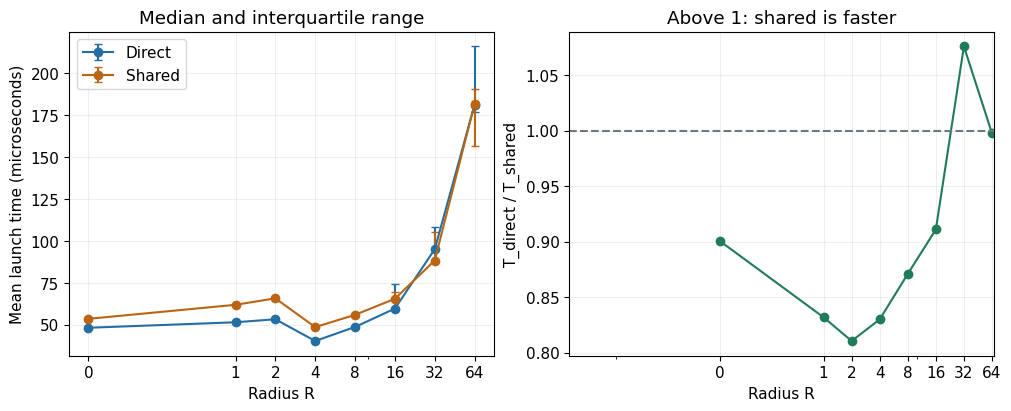

In [ ]:
import numpy as np

fig,axes=plt.subplots(1,2,figsize=(10,4),constrained_layout=True)
x=radius_results['R'].to_numpy()
for prefix,label,color in [('direct','Direct',BLUE),('shared','Shared',ORANGE)]:
    med=radius_results[prefix+'_us'].to_numpy()
    lo=radius_results[prefix+'_Q25'].to_numpy()
    hi=radius_results[prefix+'_Q75'].to_numpy()
    axes[0].errorbar(x,med,yerr=np.array([med-lo,hi-med]),marker='o',capsize=3,label=label,color=color)
axes[0].set(xlabel='Radius R',ylabel='Mean launch time (microseconds)',title='Median and interquartile range')
axes[0].legend()
axes[1].plot(x,radius_results['ratio'],marker='o',color=GREEN)
axes[1].axhline(1,color=GRAY,linestyle='--')
axes[1].set(xlabel='Radius R',ylabel='T_direct / T_shared',title='Above 1: shared is faster')
for ax in axes:
    ax.set_xscale('symlog',linthresh=1)
    ax.set_xticks(x)
    ax.set_xticklabels([str(int(r)) for r in x])
    ax.grid(alpha=.2)
display(fig)
plt.close(fig)

### Interpret the radius experiment

At R=0 each output only needs one input. The shared version offers no reuse benefit
and still stages the input and executes a barrier. This is a useful control case.

For an interior block, the direct kernel makes B(2R+1) source-level global reads;
the shared kernel makes B+2R. Their nominal ratio is (2R+1)/(1+2R/B), but it is
**not a predicted timing ratio**. Automatic caches can already supply repeated
inputs in the direct kernel. Shared memory adds explicit stores, subsequent
shared reads, and `__syncthreads()`.

Look for radii where the measured ratio rises above one. If it does not, report
that result: increased potential reuse alone does not prove a benefit on this
GPU. A growing nominal load reduction need not produce a growing speedup because
the arithmetic also grows. Quartiles describe variability, not confidence bounds.

In [ ]:
print('Measured radius comparisons (same N and B):')
for row in radius_results.itertuples(index=False):
    nominal=(2*row.R+1)/(1+2*row.R/row.B)
    winner='shared' if row.ratio>1 else 'direct' if row.ratio<1 else 'equal'
    print(f'R={row.R:2d}: nominal request reduction {nominal:6.2f}; '
          f'measured T_direct/T_shared {row.ratio:6.3f}; lower median: {winner}.')
print('Small differences should be interpreted together with the printed quartiles.')

Measured radius comparisons (same N and B):
R= 0: nominal request reduction   1.00; measured T_direct/T_shared  0.901; lower median: direct.
R= 1: nominal request reduction   2.98; measured T_direct/T_shared  0.832; lower median: direct.
R= 2: nominal request reduction   4.92; measured T_direct/T_shared  0.810; lower median: direct.
R= 4: nominal request reduction   8.73; measured T_direct/T_shared  0.830; lower median: direct.
R= 8: nominal request reduction  16.00; measured T_direct/T_shared  0.871; lower median: direct.
R=16: nominal request reduction  29.33; measured T_direct/T_shared  0.911; lower median: direct.
R=32: nominal request reduction  52.00; measured T_direct/T_shared  1.076; lower median: shared.
R=64: nominal request reduction  86.00; measured T_direct/T_shared  0.998; lower median: direct.
Small differences should be interpreted together with the printed quartiles.


## 10. Experiment B — Change the vector length and block size

Fix R=8. Test N=4,099, 65,539, 1,048,579, 8,388,611 and B=128, 256, 512 where
supported. All lengths deliberately produce partial blocks. Each configuration
computes the same zero-extended moving average for its input length.

Increasing N changes the available parallel work and the working-set size.
Increasing B reduces halo overhead per output but also changes block scheduling
and resource use. Therefore a larger block need not be faster. The experiments
do not measure occupancy or isolate cache effects; avoid attributing every change
to a single mechanism. In particular, the tested shared buffers are small and
should not be assumed to cause a large occupancy reduction.

In [ ]:
size_results=run_cuda('--sizes')

GPU: Tesla T4; SMs: 40; shared bytes/block: 49152
Driver: 13000; runtime: 13000; toolkit: 13000; 7 trials; seed: 20261008.
Columns: N B R direct_us direct_Q25 direct_Q75 shared_us shared_Q25 shared_Q75 ratio
Times exclude allocation, transfers, validation and printing.
Repeated arrays can be cached; short event intervals can include submission gaps.
Ratio = T_direct/T_shared; values above 1 favor the shared-memory kernel.

Measured times in microseconds; quartiles describe batch variability:
      N   B  R  direct_us  direct_Q25  direct_Q75  shared_us  shared_Q25  shared_Q75  ratio
   4099 128  8      2.723       2.632       2.858      2.816       2.751       2.836  0.967
   4099 256  8      2.685       2.642       2.782      2.628       2.612       2.674  1.022
   4099 512  8      2.588       2.554       2.757      2.728       2.698       2.768  0.949
  65539 128  8      4.129       4.127       4.133      4.311       4.310       4.315  0.958
  65539 256  8      4.153       4.149      

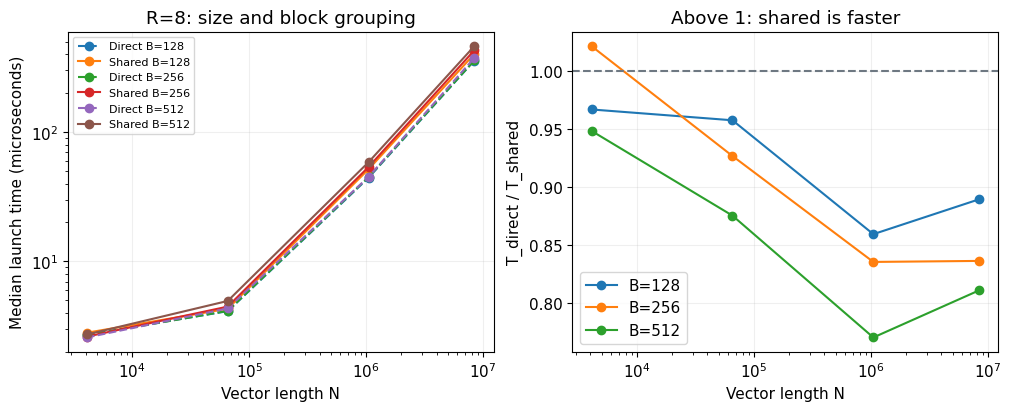

In [ ]:
fig,axes=plt.subplots(1,2,figsize=(10,4),constrained_layout=True)
for B,group in size_results.groupby('B'):
    group=group.sort_values('N')
    axes[0].plot(group['N'],group['direct_us'],marker='o',linestyle='--',label=f'Direct B={B}')
    axes[0].plot(group['N'],group['shared_us'],marker='o',label=f'Shared B={B}')
    axes[1].plot(group['N'],group['ratio'],marker='o',label=f'B={B}')
axes[0].set(xlabel='Vector length N',ylabel='Median launch time (microseconds)',title='R=8: size and block grouping')
axes[0].set_yscale('log')
axes[0].legend(fontsize=8)
axes[1].axhline(1,color=GRAY,linestyle='--')
axes[1].set(xlabel='Vector length N',ylabel='T_direct / T_shared',title='Above 1: shared is faster')
axes[1].legend()
for ax in axes:
    ax.set_xscale('log')
    ax.grid(alpha=.2)
display(fig)
plt.close(fig)

In [ ]:
print('Lowest measured median among the tested block sizes:')
for N,group in size_results.groupby('N'):
    for method in ['direct','shared']:
        best=group.loc[group[method+'_us'].idxmin()]
        print(f'N={N:,}: {method}, B={int(best["B"])}, {best[method+"_us"]:.3f} microseconds.')
print('These choices apply to the tested configurations and assigned GPU; they are not universal optima.')

Lowest measured median among the tested block sizes:
N=4,099: direct, B=512, 2.588 microseconds.
N=4,099: shared, B=256, 2.628 microseconds.
N=65,539: direct, B=128, 4.129 microseconds.
N=65,539: shared, B=128, 4.311 microseconds.
N=1,048,579: direct, B=128, 44.353 microseconds.
N=1,048,579: shared, B=128, 51.605 microseconds.
N=8,388,611: direct, B=128, 355.912 microseconds.
N=8,388,611: shared, B=128, 400.117 microseconds.
These choices apply to the tested configurations and assigned GPU; they are not universal optima.


## 11. What this experiment establishes

Compared with adjacent differences, the moving-average stencil creates more
reuse opportunities. Shared memory makes that reuse explicit, at the cost of
cooperative loads, buffer access, and a barrier. The measured tables tell whether
that tradeoff is beneficial for the GPU and configurations actually tested.

Both kernels compute each output by explicitly summing its entire window.
They serve as comparable examples of memory reuse. Prefix sums, rolling-sum
algorithms, and optimized library implementations are separate algorithmic
choices and are not compared here.

The buffer allocation and barrier follow the
[CUDA Programming Guide](https://docs.nvidia.com/cuda/cuda-programming-guide/02-basics/writing-cuda-kernels.html).